<a href="https://colab.research.google.com/github/Jolieyolie/Applied_Machine_Learning/blob/main/cloud_baseline_model_colab(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import os
from PIL import Image
from pathlib import Path
import json
import random
import torch

from sklearn.model_selection import train_test_split
import torch
import torchvision.transforms as transforms

#to follow progres during training (train time)
from tqdm import tqdm

#for R CNN model
from torch.utils.data import DataLoader, Subset #for sample table
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
#for sample table
import matplotlib.pyplot as plt

#for test of new image on pretrained model
import cv2

# and for iou
from collections import namedtuple
import numpy as np

#for maP
!pip install torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

#for randomness
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.5 MB/s eta 0:00:00


In [6]:
import zipfile
#pathway to drive file
from google.colab import drive
drive.mount('/content/drive')
!find "/content/drive/MyDrive" -name "Clouds-1000.zip"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab_Notebooks/Clouds-1000.zip


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

zip_path = "/content/drive/MyDrive/Colab_Notebooks/Clouds-1000.zip"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("dataset")

# Corrected paths to refer to the extracted dataset
extracted_base_path = Path('dataset/Clouds-1000') # Assuming the zip extracts to Clouds-1000 inside 'dataset'
dir_all = extracted_base_path / 'all_images_and_labels'
#copy all to content, to avoid long loading time with drive mounting (once)
#import shutil
#shutil.copytree('/content/drive/MyDrive/Clouds-1000', '/content/Clouds-1000')

#resize all images before transform, too speed up training size
image_path=dir_all/'images'
mask_path=dir_all/'masks'
orig_path = Path('dataset/Clouds-1000/all_images_and_labels/images') # Use correct path for original images
small_path = dir_all / 'images_small'
#resized images already uploaded
small_path.mkdir(exist_ok=True)

# Uncommented code to resize images and save them to small_path
for img_path in orig_path.glob('*.jpg'):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((224, 224))
    img.save(small_path / img_path.name)

image_files=list(sorted(small_path.glob('*.jpg')))
mask_files=list(sorted(mask_path.glob('*.json')))

In [14]:
#baseline model: faster R CNN
#https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96

# Load the pre-trained Faster R-CNN model with a ResNet-50 backbone
model_a = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
num_classes = 6  #number of classes + background for training
in_features = model_a.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
#change only last layer
model_a.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) #replace model's head with new one (for number of classes in dataset)

#prepare data for R CNN
# Define transformations (equal to ResNet18 baseline) & resize images for smaller data
transform = transforms.Compose([ #withoug transforms.Resize((224, 224)), as done already before loading
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
]) #mean and std for generalized ImageNet dataset for RGB values

#create Custom Dataset to organise data in boxes/polygons and labels/classes
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, df, transforms=None):
        self.df = df
        self.transform = transforms
        self.classes = ['Arvore', 'Estratocumuliformes', 'Cirriformes', 'Estratiformes', 'Cumuliformes']
        #i+1, to let all 5 classes count, and not confound with background
        self.class_to_idx = {c: i+1 for i, c in enumerate(self.classes)}

    def __len__(self):   #detect len for batches
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['images']).convert('RGB')
        orig_w, orig_h = 2592, 1944   #from presized images (small_path), so set up original sizes here
        with open(self.df.iloc[idx]['masks']) as f:
            data = json.load(f)

        boxes, labels = [], []
        for obj in data['objects']:
            polygon = obj['points']['exterior']
            x_coords = [p[0] for p in polygon]
            y_coords = [p[1] for p in polygon]

            #to avoid unvalid boxes
            x1, y1, x2, y2 = min(x_coords), min(y_coords), max(x_coords), max(y_coords)
            if x2 <= x1 or y2 <= y1:
              continue
            boxes.append([min(x_coords), min(y_coords), max(x_coords), max(y_coords)])
            labels.append(self.class_to_idx[obj['classTitle']])

        #filter for empty boxes
        if len(boxes) == 0:
          boxes = [[0, 0, 1, 1]]
          labels = [0]

        #scale boxes to 224x224
        scale_x = 224 / orig_w
        scale_y = 224 / orig_h
        boxes = [[x1*scale_x, y1*scale_y, x2*scale_x, y2*scale_y] for x1,y1,x2,y2 in boxes]

        target = {}
        target["boxes"] = torch.tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.tensor(labels, dtype=torch.int64)

        if self.transform is not None:
            img = self.transform(img)

        return img, target



In [15]:
#list of all learnable parameters of r cnn model (model_a)
for name, param in model_a.named_parameters():
    print(name, param.shape)

backbone.body.conv1.weight torch.Size([64, 3, 7, 7])
backbone.body.layer1.0.conv1.weight torch.Size([64, 64, 1, 1])
backbone.body.layer1.0.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.0.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.0.downsample.0.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.1.conv1.weight torch.Size([64, 256, 1, 1])
backbone.body.layer1.1.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.1.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer1.2.conv1.weight torch.Size([64, 256, 1, 1])
backbone.body.layer1.2.conv2.weight torch.Size([64, 64, 3, 3])
backbone.body.layer1.2.conv3.weight torch.Size([256, 64, 1, 1])
backbone.body.layer2.0.conv1.weight torch.Size([128, 256, 1, 1])
backbone.body.layer2.0.conv2.weight torch.Size([128, 128, 3, 3])
backbone.body.layer2.0.conv3.weight torch.Size([512, 128, 1, 1])
backbone.body.layer2.0.downsample.0.weight torch.Size([512, 256, 1, 1])
backbone.body.layer2.1.conv1.weight t

In [18]:
df=pd.DataFrame({'images': image_files, 'masks': mask_files})
# split into train, val, test sets: train_size=0.7, test_size=0.15 * 2
train_df, rest_df=train_test_split(df, test_size=0.4, random_state=42) #60% train
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42) #je 20%

#check size
print(f"Set sizes:\nTrain:\t{len(train_df)}")  #60%
print(f"Val:\t{len(val_df)}")  #20%
print(f"Test:\t{len(test_df)}")  #20%

#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

Set sizes:
Train:	597
Val:	199
Test:	200


In [20]:
#to check, if boxes are succesfully resized
_, target = train_ds[0]
print("Boxes:\n",   target["boxes"])
print("Max coord:", target["boxes"].max().item())
print("Labels:",    target["labels"])

Boxes:
 tensor([[  0.0000,  67.5226, 162.6420, 198.8807],
        [  0.0000,   0.0000, 178.7160,  68.9053],
        [  0.0000, 125.3663, 223.9136, 223.8848]])
Max coord: 223.91357421875
Labels: tensor([2, 4, 1])


In [21]:
#training
model_a.to(device)

#hidden layer einfrieren
for param in model_a.parameters():
  param.requires_grad=False
for param in model_a.roi_heads.box_predictor.parameters():
  param.requires_grad=True

# Set up the optimizer
params = [p for p in model_a.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
num_epochs = 15
for epoch in range(num_epochs):
    model_a.train()
    train_loss = 0.0

    # Training loop
    #with loading bar
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()

        # Forward pass
        loss_dict = model_a(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backward pass
        losses.backward()
        optimizer.step()
        train_loss += losses.item()

    # Update learning rate
    lr_scheduler.step()
    print(f'Epoch: {epoch + 1}, Loss: {train_loss / len(train_loader)}')
    print("Training complete!")


Epoch 1/15: 100%|██████████| 150/150 [00:51<00:00,  2.92it/s]


Epoch: 1, Loss: 0.8544138489166896
Training complete!


Epoch 2/15: 100%|██████████| 150/150 [00:50<00:00,  3.00it/s]


Epoch: 2, Loss: 0.7516874422629675
Training complete!


Epoch 3/15: 100%|██████████| 150/150 [00:51<00:00,  2.91it/s]


...

Epoch: 13, Loss: 0.7302352884411811
Training complete!


Epoch 14/15: 100%|██████████| 150/150 [00:56<00:00,  2.64it/s]


Epoch: 14, Loss: 0.727275173664093
Training complete!


Epoch 15/15: 100%|██████████| 150/150 [00:56<00:00,  2.66it/s]

Epoch: 15, Loss: 0.7253321392337481
Training complete!


In [22]:
#evaluate training (without gradient calculation, only prediction: no_grad)
model_a.eval()
map_a=MeanAveragePrecision()
with torch.no_grad():
  for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
    images=list(img.to(device) for img in images)
    prediction=model_a(images) #forward calculation through call
    preds_boxes=prediction[0]['boxes']
    true_boxes=targets[0]['boxes']
    #print bounding boxes for first images as example
    print(prediction[0]['boxes'])
    print(prediction[0]['labels'])

    #for maP change to cpu (not gpu compatible)
    true_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
    preds_cpu = [{k: v.cpu() for k, v in p.items()} for p in prediction]

    map_a.update(preds_cpu, true_cpu)
result=map_a.compute()


tensor([[  0.0000, 148.3338, 224.0000, 224.0000],
        [  0.0000,   0.2742, 223.8478, 201.3383],
        [ 64.3673, 170.9852, 224.0000, 224.0000],
        [  9.8182,   1.3012, 215.4516, 108.2563],
        [  6.2683, 155.9289, 126.9975, 224.0000],
        [ 62.9548, 117.0239, 217.2304, 207.8766],
        [  0.0000,   2.7209, 134.0844, 167.8936],
        [  4.2951, 132.1871, 218.8057, 188.5843],
        [  0.0000,  89.0651, 224.0000, 200.3483],
        [  0.0000,  14.8199, 224.0000, 177.6397],
        [  6.5945,   1.2852, 215.8804, 104.4323],
        [ 98.5929,   8.4586, 218.3923, 123.6110],
        [ 18.1109,   2.1939, 214.6467,  41.0760],
        [  0.0000, 133.9341, 218.6150, 184.7772],
        [ 21.0034, 155.8351, 224.0000, 197.8930],
        [ 99.7391, 158.5725, 220.5581, 206.1597],
        [  4.7587, 102.7061, 216.6574, 172.7091],
        [106.2470, 109.2102, 169.5962, 131.4009],
        [  0.0000, 158.1218, 171.6695, 195.2028],
        [129.8459,  16.0172, 150.8649,  31.6222],


In [23]:
#print(f'Mean Average Prediction (maP score): {result}')
print(f'Mean Average Prediction (maP score): {result['map']:.4f}')

Mean Average Prediction (maP score): 0.1637


In [24]:
#IoU:Intersection over Union to evaluate accuracy of boxes = area of overlap/total area of true & predicted box (=union))
#compare: iou>0.5 looks good (https://pyimagesearch.com/2016/11/07/intersection-over-union-iou-for-object-detection/)
#1. define the 'detection' object that stores the 3 attributes: folder, original box, predicted box
Detection = namedtuple("Detection", ["image_path", "true", "pred"])
#2. define function for intersection/overlapping
def bb_intersection_over_union(boxA, boxB):
	# determine (x, y)-coordinates of intersection rectangle
	xA = max(boxA[0], boxB[0])
	yA = max(boxA[1], boxB[1])
	xB = min(boxA[2], boxB[2])
	yB = min(boxA[3], boxB[3])
	#compute area of intersection rectangle
	interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)
	#compute area of prediction and ground-truth (true) rectangles
	boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
	boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)
	#compute intersection over union by taking intersection area and dividing by:
  #prediction + ground-truth areas - the intersection area
	iou_a = interArea / float(boxAArea + boxBArea - interArea)
	#return intersection over union value
	return iou_a

In [25]:
#check trained model success for new image
#Load random image
img = Image.open(small_path/'2021-06-03_15-46-00.jpg')
# Apply same transformation as for training
img = transform(img)
img=img.to(device)
#Model prediction
model_a.eval()
with torch.no_grad():
    prediction = model_a([img])
# Print the predicted bounding boxes and labels
print(prediction[0]['boxes'])
print(prediction[0]['labels'])

img_picture=transforms.ToPILImage() #STILL NORMALIZED!!

tensor([[0.0000e+00, 1.6364e+02, 2.2354e+02, 2.2400e+02],
        [1.4767e+01, 6.0777e+01, 2.0561e+02, 2.1308e+02],
        [1.2427e+01, 0.0000e+00, 2.2038e+02, 8.1270e+01],
        [5.0768e+00, 6.5056e+01, 2.1950e+02, 1.9359e+02],
        [8.3506e+00, 1.7603e+02, 1.4781e+02, 2.2400e+02],
        [2.1866e-02, 1.2897e+02, 2.0916e+02, 1.8872e+02],
        [7.7343e+00, 6.1971e+01, 2.1901e+02, 1.7919e+02],
        [3.6111e+01, 0.0000e+00, 2.2400e+02, 1.7272e+02],
        [2.3436e+01, 3.5603e+01, 1.9596e+02, 1.5534e+02],
        [9.9694e+01, 1.6877e+02, 2.1376e+02, 2.2400e+02],
        [0.0000e+00, 1.3994e+02, 1.9257e+02, 1.9272e+02],
        [2.2360e+00, 9.6257e+00, 2.1005e+02, 1.2892e+02],
        [3.7028e-01, 7.4429e+01, 1.5084e+02, 1.4045e+02],
        [6.5576e+01, 9.2286e+01, 2.1123e+02, 1.6285e+02],
        [2.3539e+01, 5.6342e-01, 2.2000e+02, 1.5826e+02],
        [0.0000e+00, 1.5546e+02, 1.9518e+02, 1.9755e+02],
        [6.7696e+01, 0.0000e+00, 2.2029e+02, 5.0087e+01],
        [1.699

In [26]:
#train:80
train_df, rest_df=train_test_split(df, test_size=0.2, random_state=42) #60% train
val_df, test_df=train_test_split(rest_df, test_size=0.5, random_state=42) #je 20%
#load datasets
train_ds = CustomDataset(train_df, transforms=transform)
val_ds   = CustomDataset(val_df,   transforms=transform)
test_ds=CustomDataset(test_df, transforms=transform)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))
test_loader=DataLoader(test_ds, batch_size=4, shuffle=True, num_workers=0, #load parallel
                          pin_memory=True, #faster gpu
                          collate_fn=lambda x: tuple(zip(*x)))

#check how much training data is needed for success (with map)
sample_size=[50, 100, 300, 500, len(train_df)]
map_results={}
for s in sample_size:
  print(f'Amount of Training Data: {s}')
  set_seed(42)
  sample_ds=Subset(train_ds, list(range(s)))
  sample_loader=DataLoader(sample_ds,batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

  #reinitialize model_a with subset
  model_s = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
  in_features = model_s.roi_heads.box_predictor.cls_score.in_features #get number of input features for classifier
  model_s.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) #replace model's head with new one (for number of classes in dataset)
  #freeze hidden layer
  for param in model_s.parameters():
    param.requires_grad=False
  for param in model_s.roi_heads.box_predictor.parameters():
    param.requires_grad=True

  model_s.to(device)
  params = [p for p in model_s.parameters() if p.requires_grad]
  optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
  lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
  num_epochs = 3 #15?
  for epoch in range(num_epochs):
      model_s.train() #no saving/later use of trainloss necessary
      # Training loop
      for images, targets in tqdm(sample_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
          images = list(image.to(device) for image in images)
          targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
          optimizer.zero_grad()
          loss_dict = model_s(images, targets)
          losses = sum(loss_dict.values())
          losses.backward()
          optimizer.step()

      # Update learning rate (when num_epochs>10)
      #lr_scheduler.step()
      print(f'Epoch: {epoch + 1}')
      print("Training complete!")

  #evaluate training (without gradient calculation, only prediction: no_grad)
  model_s.eval()
  map_s=MeanAveragePrecision()
  with torch.no_grad():
    for images, targets in valid_loader: #targets optional as _, as it is not used here, only appearing in tupel (getitem)
        images=list(img.to(device) for img in images)
        preds  = model_s(images)
        map_s.update([{k: v.cpu() for k, v in p.items()} for p in preds],
                [{k: v.cpu() for k, v in t.items()} for t in targets]
            )
  result_s=map_s.compute()
  map_results[s] = result_s['map'].item()
  print(f'Amount={s}: maP = {map_results[s]:.4f}')

Amount of Training Data: 50


Epoch 1/3: 100%|██████████| 13/13 [00:04<00:00,  2.85it/s]


Epoch: 1
Training complete!


Epoch 2/3: 100%|██████████| 13/13 [00:04<00:00,  2.88it/s]


Epoch: 2
Training complete!


...

Epoch: 1
Training complete!


Epoch 2/3: 100%|██████████| 199/199 [01:16<00:00,  2.60it/s]


Epoch: 2
Training complete!


Epoch 3/3: 100%|██████████| 199/199 [01:16<00:00,  2.60it/s]


Epoch: 3
Training complete!
Amount=796: maP = 0.1722


In [27]:
#print table
print(f'Amount of Training Data and Quality of Outcome\n')
for s,m in map_results.items():
  print(f'Amount of Training Data: {s}\tmaP: {m:.4f}')

Amount of Training Data and Quality of Outcome

Amount of Training Data: 50	maP: 0.1054
Amount of Training Data: 100	maP: 0.1162
Amount of Training Data: 300	maP: 0.1523
Amount of Training Data: 500	maP: 0.1552
Amount of Training Data: 796	maP: 0.1722


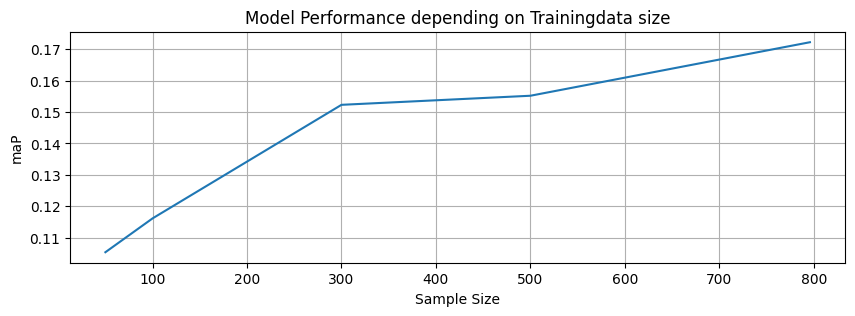

In [28]:
#visualitze table
plt.figure(figsize=(10,3))
plt.plot(list(map_results.keys()), list(map_results.values()))
plt.title('Model Performance depending on Trainingdata size')
plt.xlabel('Sample Size')
plt.ylabel('maP')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/Colab_Notebooks/Clouds-1000/Performance_SampleSize.jpeg')
plt.show()